# Performing GBM Spectral Analysis of GRB 190114C

This is a tutorial for performing spectral analysis of a GBM GRB with the Gamma-ray Data Tools (GDT). In this tutorial, we are going to analyze GRB 190114C / 190114.873

First, we need to choose which NaI and BGO detectors to use. The NaI detectors should view the source (i.e., source angle < 60 deg) and should not be blocked by the spacecraft. Blocked NaI detectors are typically blocked if the observed intensity is less than about 50% of the intensity of the brightest detector. To be safe, you can match the detectors used in the T90 analysis and can be found in the BCAT (and SCAT) file(s). One or both BGO detectors can be used, but it is generally a good idea to include the BGO facing the burst even if there is no detectable signal, as the upper limits may constrain the spectrum. 

In [1]:
from gdt.missions.fermi.gbm.finders import TriggerFinder
from glob import glob

# Define your GRB and data path
grb = '190114873'
data_path = '/shared/fermi-data/{}/'.format(grb)

data_finder = TriggerFinder(grb)

**Check detectors used in the T90**

In [2]:
#from astropy.io import fits

# download catalog files, if necessary
#data_finder.get_cat_files(data_path, verbose=True)

# Read the BCAT file to get the detectors
#bcat_path = data_path+'glg_bcat_all_bn{}_v0*.fit'.format(grb)
#bcat = glob(bcat_path)[0]

# Open the BCAT and get detector names
#bcat = fits.open(bcat)[1]

# Print the detector names
#print (bcat.data['DETNAM'])

### Downloading the spectral analysis data

Here, we'll download the detector data and response files for the GRB from HEASEARC. We'll first try to download the TTE files, but if they're not available, then we will ask if you want to download CSPEC files. If the burst is too short for CSPEC resolution (0.256 s), then you will have to use TTE data and CSPEC files will not be what you want. If neither TTE or CSPEC files are available, you'll have to wait for the data to be made.

In [3]:
# Define the detectors to use in spectral analysis
good_nais = ['n3', 'n4', 'n8']
good_bgos = ['b0']
good_dets = good_nais + good_bgos

In [4]:
# Download the CSPEC data
data_finder = TriggerFinder(grb)
data_finder.get_cspec(data_path, dets=good_dets, verbose=True)

# Download the detector response files
rsp_finder = data_finder.get_rsp2(data_path, cspec=True, ctime=False, dets=good_dets, verbose=True)

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

In [8]:
from gdt.missions.fermi.gbm.phaii import Cspec
from gdt.missions.fermi.gbm.collection import GbmDetectorCollection

# Load TTE files for each NaI and BGO detector
nai_cspecs = [Cspec.open(data_path+'/glg_cspec_'+nai+'_bn'+str(grb)+'_v00.pha') for nai in good_nais]
bgo_cspecs = [Cspec.open(data_path+'/glg_cspec_'+bgo+'_bn'+str(grb)+'_v00.pha') for bgo in good_bgos]

**Bin TTE to desired time resolution**

In [48]:
from gdt.core.binning.unbinned import bin_by_time 

# Combine detectors
detector_cspecs = nai_cspecs + bgo_cspecs

# Bin TTE by time
# Desired temporal resolution in seconds
#t_res = 1.024 
#detector_cspecs = [det.to_phaii(bin_by_time, t_res) for det in detector_cspecs]

# create a collection from the list of our files
cspecs = GbmDetectorCollection.from_list(detector_cspecs, names=good_dets, dets=good_dets)

In [14]:
# Adjust view_range as needed
view_range = (-100.0, 200.0) # zoom in to this time range

erange_nai = (9.0, 750.0)   # in keV
erange_bgo = (200.0, 35000.0) # in keV

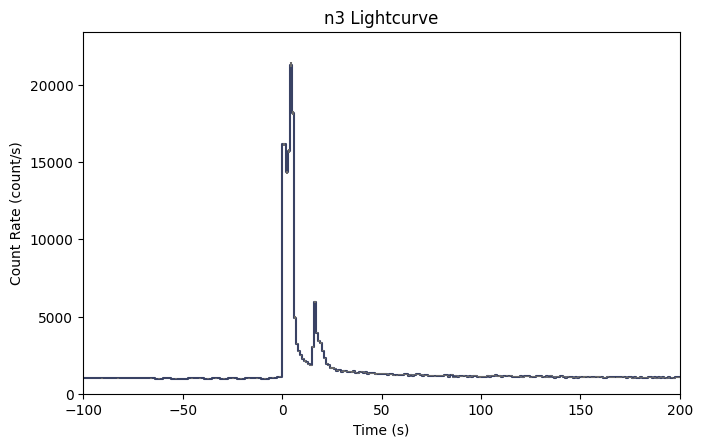

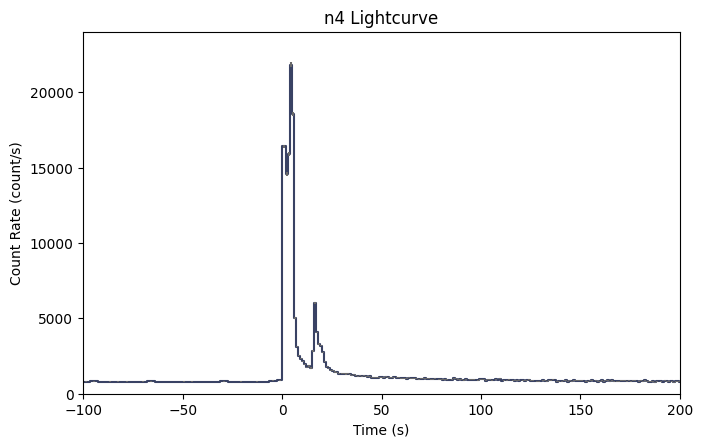

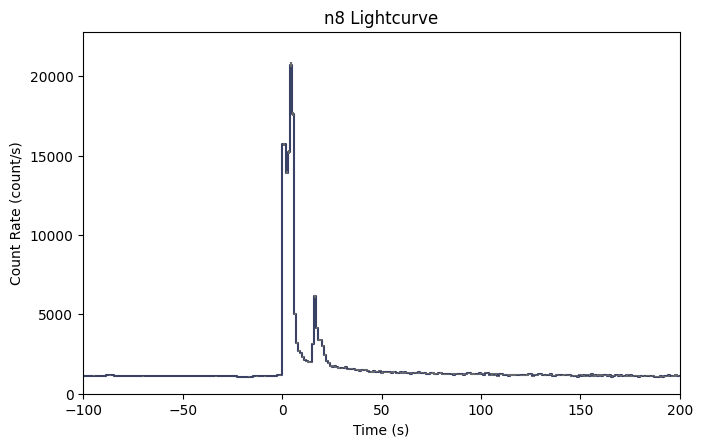

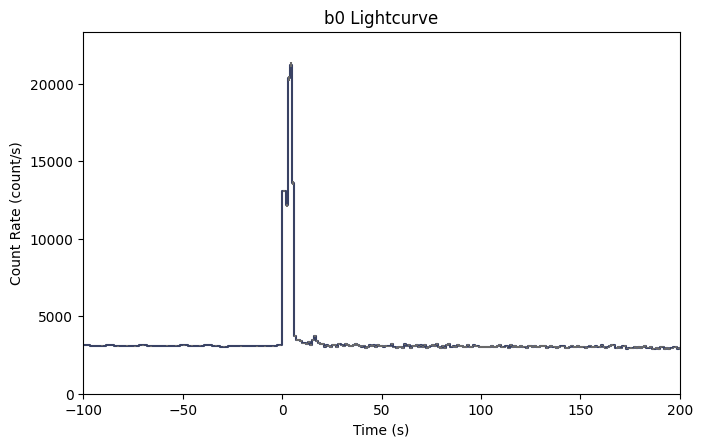

In [16]:
from gdt.core.plot.lightcurve import Lightcurve
from gdt.core.plot.spectrum import Spectrum

# Get the data from the CSPEC files
data_lcs = cspecs.to_lightcurve(nai_kwargs={'energy_range':erange_nai}, bgo_kwargs={'energy_range':erange_bgo})

# Plot the lightcurves
lc_plots = [Lightcurve(data=data_lc, label=det) for data_lc, det in zip(data_lcs, good_dets)]
for lc_plot in lc_plots:
    lc_plot.xlim = view_range
    lc_plot.ax.set_title('{} Lightcurve'.format(lc_plot.ax.get_label()))

In [19]:
# Select source time range
src_range = (0.003, 38.593)

# Add source selections to the lightcurves
src_lcs = cspecs.to_lightcurve(time_range=src_range, nai_kwargs={'energy_range':erange_nai}, bgo_kwargs={'energy_range':erange_bgo})
src_specs = cspecs.to_spectrum(time_range=src_range, nai_kwargs={'energy_range':erange_nai}, bgo_kwargs={'energy_range':erange_bgo})

# Add source selection to the spectra
data_specs = cspecs.to_spectrum(time_range=src_range)
src_specs = cspecs.to_spectrum(time_range=src_range, nai_kwargs={'energy_range':erange_nai}, bgo_kwargs={'energy_range':erange_bgo})

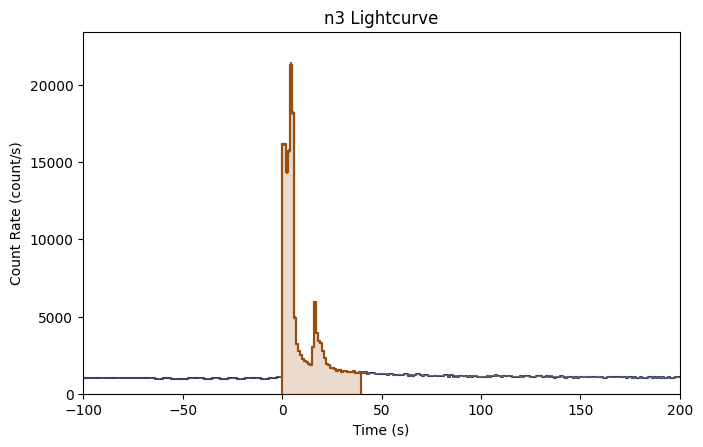

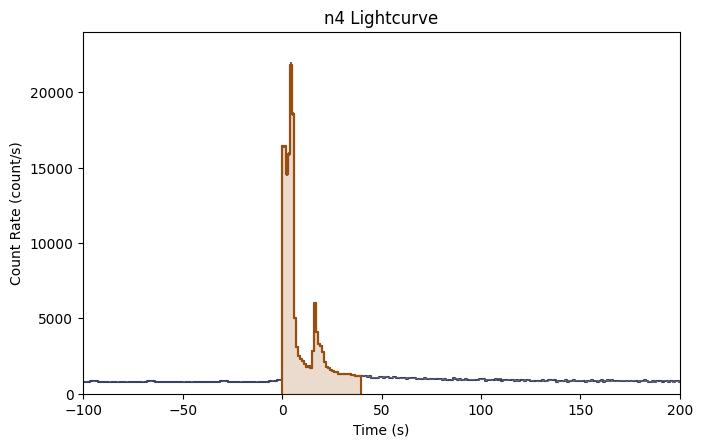

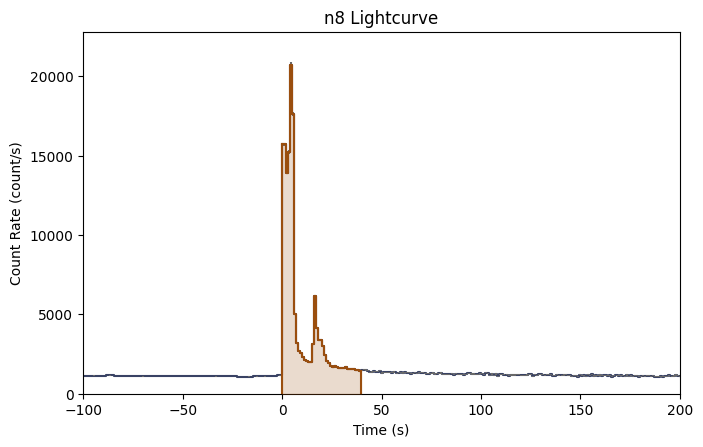

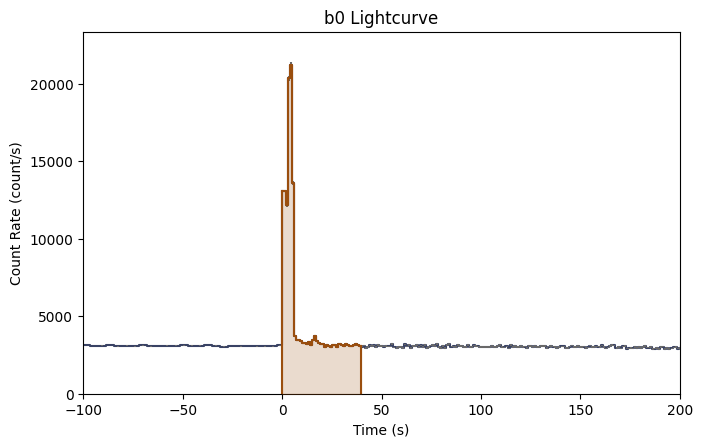

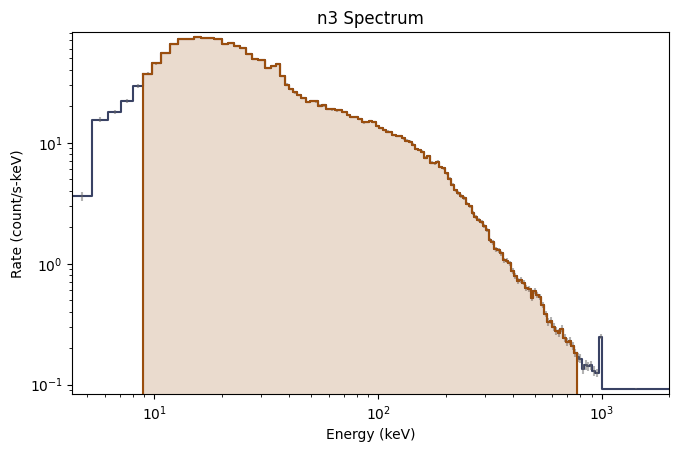

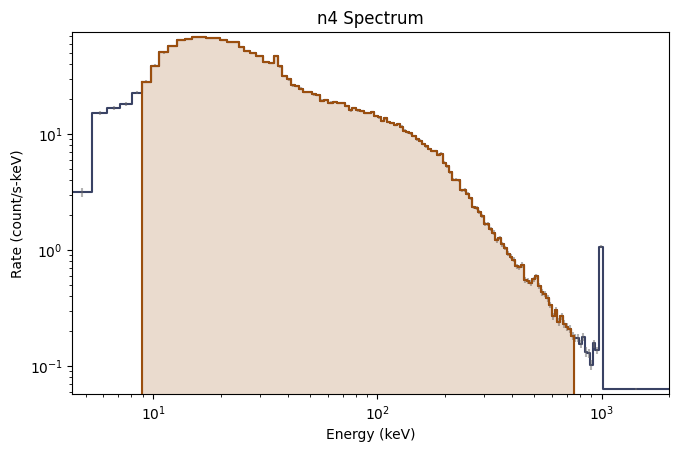

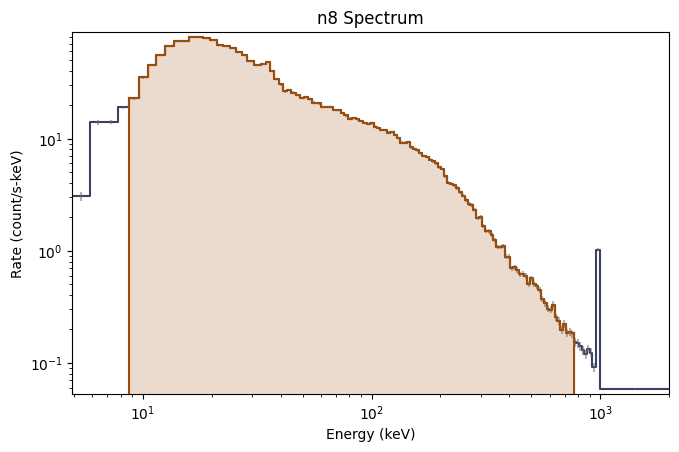

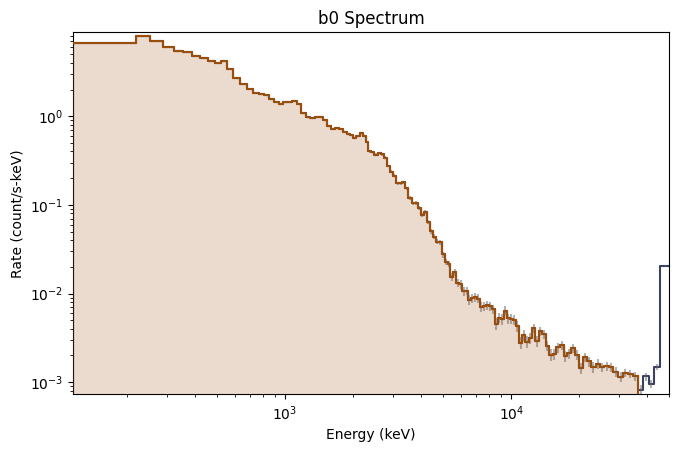

In [21]:
# Plot the lightcurves and source selections
lc_plots = [Lightcurve(data=data_lc, label=det) for data_lc, det in zip(data_lcs, good_dets)]
_ = [lcplot.add_selection(src_lc) for lcplot, src_lc in zip(lc_plots, src_lcs)]
for lc_plot in lc_plots:
    lc_plot.xlim = view_range
    lc_plot.ax.set_title('{} Lightcurve'.format(lc_plot.ax.get_label()))

# Plot the spectra
spec_plots = [Spectrum(data=data_spec, label=cspec.detector) for data_spec, cspec in zip(data_specs,cspecs)]
_ = [spec_plot.add_selection(src_spec) for spec_plot, src_spec in zip(spec_plots, src_specs)]
for spec_plot in spec_plots:
    spec_plot.ax.set_title('{} Spectrum'.format(spec_plot.ax.get_label()))

In [35]:
# Select background ranges and polynomial order
bkgd_range = [(-150, -15.), (200., 400.)]    # background fit ranges
order = 1                                    # background polynomial order

In [36]:
from gdt.core.background.binned import Polynomial
from gdt.core.background.fitter import BackgroundFitter

# Initialize the background fitters 
bkgd_fitters = [BackgroundFitter.from_phaii(cspec, Polynomial, time_ranges=bkgd_range) for cspec in cspecs]
# Add fittiers to collection, making sure the collection knows which background goes with which detector
bkgd_fitters = GbmDetectorCollection.from_list(bkgd_fitters, dets=good_dets, names=good_dets)

# Perform the fit
bkgd_fitters.fit(order=order)

In [37]:
# Interpolate/extrapolate fit and store in a collection
bkgds = bkgd_fitters.interpolate_bins(cspecs.data()[0].tstart, cspecs.data()[0].tstop)
bkgds = GbmDetectorCollection.from_list(bkgds, dets=good_dets, names=good_dets)

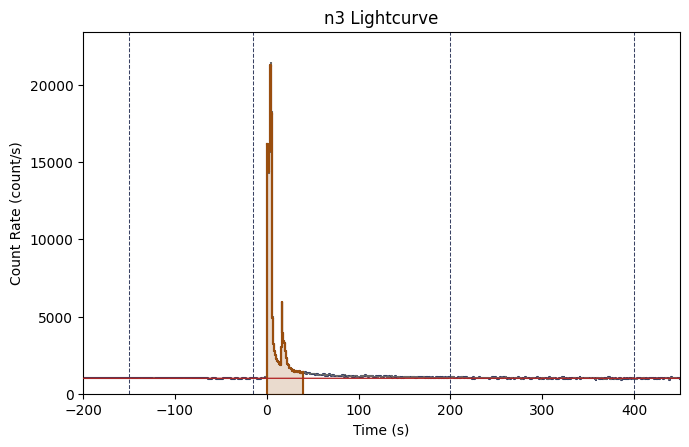

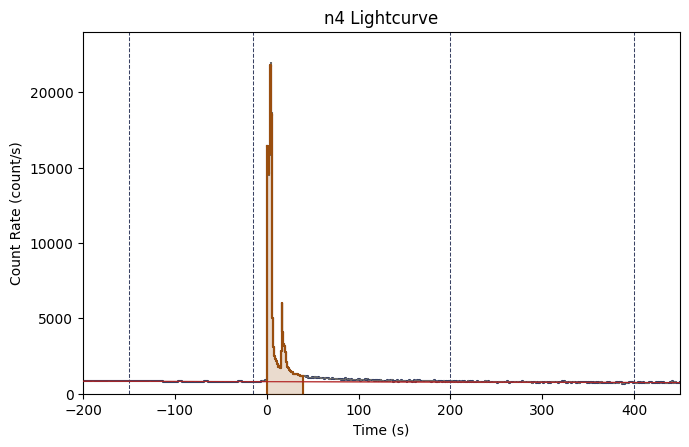

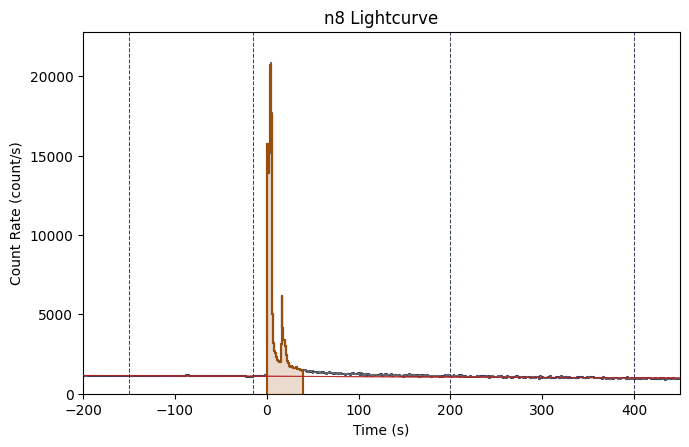

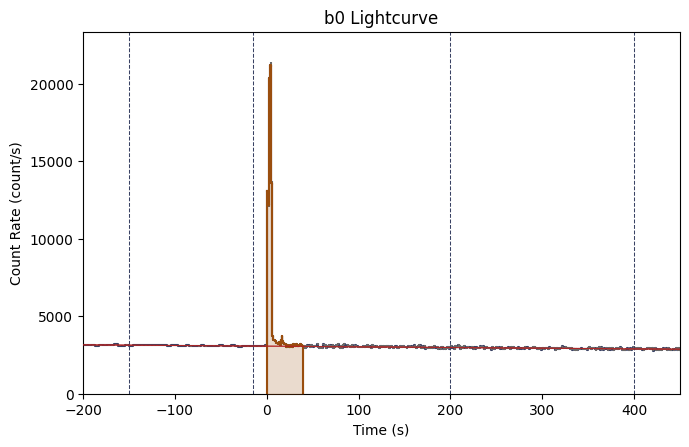

In [38]:
# Make the energy-integrated background
bkgd_lcs = bkgds.integrate_energy(nai_args=erange_nai, bgo_args=erange_bgo)

# Plot the lightcurves and background fit
lc_plots = [Lightcurve(data=data_lc, background=bkgd_lc, label=det) for data_lc, bkgd_lc, det in zip(data_lcs, bkgd_lcs, good_dets)]
# Plot lightcurve source selections
_ = [lcplot.add_selection(src_lc) for lcplot, src_lc in zip(lc_plots, src_lcs)]

for lc_plot in lc_plots:
    lc_plot.xlim = (-200, 450)
    #lc_plot.ylim = (100, 5000)
    lc_plot.ax.set_title('{} Lightcurve'.format(lc_plot.ax.get_label()))
    # Show background intervals
    for bkgd_int in bkgd_range:
        lc_plot.ax.axvline(bkgd_int[0], color=lc_plot.lightcurve.color, linewidth=0.75, linestyle='--')
        lc_plot.ax.axvline(bkgd_int[1], color=lc_plot.lightcurve.color, linewidth=0.75, linestyle='--') 

In [41]:
import matplotlib.pyplot as plt

# Save lightcurve plots
for lc_plot in lc_plots:
    title = data_path+'/spec_'+lc_plot.ax.get_label().upper()+'_lc_v00.png'
    lc_plot._figure.savefig(title)
plt.close()

In [45]:
from gdt.missions.fermi.gbm.response import GbmRsp, GbmRsp2

# Find and load the Response (.rsp) file for each NaI and BGO detector
rsp_files = glob(data_path+'/glg_cspec_*_bn'+grb+'_v*.rsp2')
nai_rsps = [GbmRsp2.open(rsp_file) for rsp_file in rsp_files if 'cspec_n' in rsp_file]
bgo_rsps = [GbmRsp2.open(rsp_file) for rsp_file in rsp_files if 'cspec_b' in rsp_file]
all_rsps = nai_rsps + bgo_rsps

# Create a collection from the list of our files
rsps = GbmDetectorCollection.from_list(all_rsps)

# Create detector PHAs from the detector CSPECs
phas = cspecs.to_pha(time_ranges=src_range, nai_kwargs={'energy_range':erange_nai}, bgo_kwargs={'energy_range':erange_bgo})

# Interpolate response over lightcurve
lcs = [cspec.to_lightcurve() for cspec in cspecs]
rsps_interp = [rsp.weighted(lc, interpolate=True) for rsp,lc in zip(rsps, lcs)]
       
for rsp, pha in zip(rsps_interp, phas):
    rsp._detector = pha.filename

In [46]:
from gdt.core.spectra.functions import PowerLaw, Comptonized, Band, BlackBody

# Instantiate model functions
models = [PowerLaw(), Comptonized(), Band()]

In [47]:
import numpy as np

from gdt.core.spectra.fitting import SpectralFitterPstat, SpectralFitterPgstat
from gdt.core.plot.model import ModelFit
from gdt.core.data_primitives import Parameter

def param_list(fit_results, model_parameters, asymmetric=False):
    """
    Takes spectral fit/s and ties the model parameter name to 
    the spectral fit values and uncertainties
    
    Args:
        fit_results: list of gdt.core.spectra.fitting.FITTER objects
            the spectral fit results
        model_parameters: param_list() from gdt.core.spectra.functions objects
            the spectral models used

    Returns:
    list of gdt.core.data_primitive.Parameter objects
    """
    plist = []
    if asymmetric is not False:
        for (pml, pp, pae) in zip(model_parameters, 
                                  fit_results.parameters, 
                                  fit_results.asymmetric_errors()):
            plist.append(Parameter(pp, tuple(pae), name=pml[0], units=pml[1]))
    else:
        for (pml, pp, pae) in zip(model_parameters, 
                                  fit_results.parameters, 
                                  fit_results.symmetric_errors):
            plist.append(Parameter(pp, pae, name=pml[0], units=pml[1]))
    return plist

# Perform fit
fit_results = []

for model in models:
    specfitter = SpectralFitterPgstat(phas, bkgds.to_list(), rsps_interp, method='Nelder-Mead')
    
    print ('Fitting with {} model ...'.format(model.name))
    specfitter.fit(model, options={'maxiter': 10000})
    fit_results.append(specfitter)

    # Print fit results
    print (['Converged' if 'Converged' in specfitter.message else specfitter.message][0])
    
    spec_str = 'Best-fit parameters:'
    plist = param_list(specfitter, model.param_list, asymmetric=True)
    for p in plist:
        spec_str += '\n{0:6}: {1:8} +/- {2}'.format(p.name, np.round(p.value, 4), np.around(p.uncertainty, 5))
        
    spec_str += '\nPstat/DoF: {}/{}\n'.format(np.round(specfitter.statistic,3), specfitter.dof)
    print (spec_str) 

Fitting with PowerLaw model ...
Optimization terminated successfully.
Best-fit parameters:
A     :   0.0818 +/- [0.00021 0.00021]
index :  -1.4179 +/- [0.00158 0.00159]
Pstat/DoF: 16057.752/460

Fitting with Comptonized model ...


/opt/anaconda/envs/fermigbm/lib/python3.11/site-packages/gdt/core/spectra/fitting.py:1213: RuntimeWarning: divide by zero encountered in divide
  f_alt = (2.0 * r) / (-q + d)


Optimization terminated successfully.
Best-fit parameters:
A     :   0.1032 +/- [0.00033 0.00033]
Epeak : 1276.5411 +/- [18.67839 19.03684]
index :  -1.1372 +/- [0.00345 0.00345]
Pstat/DoF: 3573.257/459

Fitting with Band model ...
Optimization terminated successfully.
Best-fit parameters:
A     :   0.1055 +/- [0.00039 0.00039]
Epeak : 1022.5393 +/- [15.56028 15.87017]
alpha :  -1.1266 +/- [0.00406 0.00407]
beta  :  -2.0001 +/- [7.9999 0.    ]
Pstat/DoF: 4363.531/458



/opt/anaconda/envs/fermigbm/lib/python3.11/site-packages/gdt/core/spectra/fitting.py:342: UserWarning: Parameter exists at its lower bound
  warnings.warn("Parameter exists at its lower bound")
/opt/anaconda/envs/fermigbm/lib/python3.11/site-packages/gdt/core/spectra/fitting.py:371: UserWarning: Parameter exists at its upper bound
  warnings.warn("Parameter exists at its upper bound")


/opt/anaconda/envs/fermigbm/lib/python3.11/site-packages/gdt/core/plot/model.py:137: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self._ax.legend()


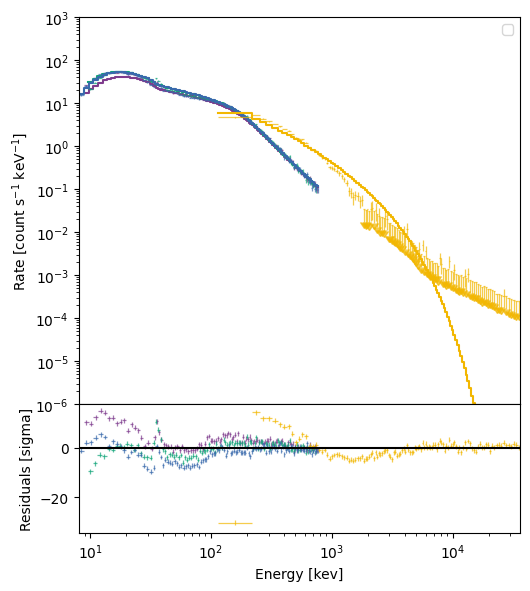

In [49]:
# Plot best spectral model and data
best_fit = fit_results[1]
modelplot = ModelFit(fitter=best_fit)

# Modify y axis for Comptonized function
if best_fit.function_name == 'Comptonized':
    modelplot.ax.set_ylim(0.000001, 1000)